## RNG

In [3]:
import numpy as np

seed = 42
rng = np.random.default_rng(seed)

## Tworzenie środowiska

In [4]:
import gymnasium as gym

env = gym.make("LunarLander-v3")

_OBS_SIZE = env.observation_space.shape[0]
_ACTION_SIZE = env.action_space.n

## Klasa reprezentująca sieć neuronową

In [5]:
_LAYER_SIZES = [_OBS_SIZE, 64, 64, _ACTION_SIZE]

class NeuralNetwork:
    def __init__(self, layer_sizes):
        self.weights = []
        self.biases = []

        for i in range(len(layer_sizes) - 1):
            self.weights.append(rng.standard_normal((layer_sizes[i], layer_sizes[i + 1])) * 0.5)
            self.biases.append(np.zeros(layer_sizes[i + 1]))

    def forward(self, x):
        for i in range(len(self.weights)):
            x = x @ self.weights[i] + self.biases[i]
            if i < len(self.weights) - 1:
                x = np.tanh(x)
        return np.argmax(x)

    def copy(self):
        clone = NeuralNetwork(_LAYER_SIZES)
        clone.weights = [w.copy() for w in self.weights]
        clone.biases = [b.copy() for b in self.biases]
        return clone

## Klasa reprezentująca osobnika

In [6]:
class Subject:
    def __init__(self, network):
        self.network = network
        self.fitness = None

    def evaluate_fitness(self, env, episodes=3):
        total = 0

        for _ in range(episodes):
            obs, info = env.reset()
            done = False

            while not done:
                action = self.network.forward(obs)
                obs, reward, terminated, truncated, info = env.step(action)
                total += reward
                done = terminated or truncated

        self.fitness = total / episodes

## Losowanie populacji, selekcja turniejowa, krzyżowanie, mutacja

In [7]:
def init_population(size):
    population = []

    for _ in range(size):
        subject = Subject(NeuralNetwork(_LAYER_SIZES))
        subject.evaluate_fitness(env)
        population.append(subject)

    return population

def tournament_selection(population):
    candidates = rng.choice(population, size=3, replace=False)
    best_candidate = max(candidates, key=lambda x: x.fitness)

    return best_candidate

def crossover(parent1, parent2):
    child = NeuralNetwork(_LAYER_SIZES)

    for i in range(len(child.weights)):
        w_mask = rng.random(child.weights[i].shape) < 0.5
        child.weights[i] = np.where(w_mask, parent1.network.weights[i], parent2.network.weights[i])

        b_mask = rng.random(child.biases[i].shape) < 0.5
        child.biases[i] = np.where(b_mask, parent1.network.biases[i], parent2.network.biases[i])

    return Subject(child)

def mutate(subject, mutation_rate, sigma):
    for i in range(len(subject.network.weights)):
        w = subject.network.weights[i]
        w += (rng.random(w.shape) < mutation_rate) * rng.standard_normal(w.shape) * sigma

        b = subject.network.biases[i]
        b += (rng.random(b.shape) < mutation_rate) * rng.standard_normal(b.shape) * sigma

    return subject

## Główna pętla algorytmu

In [8]:
_POPULATION_SIZE = 100
_GENERATIONS = 50
_ELITE_COUNT = 5
_CROSSOVER_PROBABILITY = 0.4
_MUTATION_PROBABILITY = 0.15
_MUTATION_SIGMA_START = 0.2
_MUTATION_SIGMA_END = 0.05

population = init_population(_POPULATION_SIZE)
best_history = []
average_history = []
worst_history = []

for generation in range(_GENERATIONS):
    sigma = _MUTATION_SIGMA_START + (_MUTATION_SIGMA_END - _MUTATION_SIGMA_START) * (generation / (_GENERATIONS - 1))

    new_population = []

    elites = sorted(population, key=lambda x: x.fitness, reverse=True)[:_ELITE_COUNT]
    for elite_subject in elites:
        elite = Subject(elite_subject.network.copy())
        elite.fitness = elite_subject.fitness
        new_population.append(elite)

    while len(new_population) < _POPULATION_SIZE:
        parent1 = tournament_selection(population)
        parent2 = tournament_selection(population)

        if rng.random() < _CROSSOVER_PROBABILITY:
            child = crossover(parent1, parent2)
        else:
            best_parent = max(parent1, parent2, key=lambda x: x.fitness)
            child = Subject(best_parent.network.copy())

        child = mutate(child, _MUTATION_PROBABILITY, sigma)
        child.evaluate_fitness(env)
        new_population.append(child)

    population = new_population

    population_fitness = [x.fitness for x in population]
    best = max(population_fitness)
    average = sum(population_fitness) / len(population_fitness)
    worst = min(population_fitness)
    best_history.append(best)
    average_history.append(average)
    worst_history.append(worst)

    print(f"Generation {generation + 1}: best = {round(best, 2)}, avg = {round(average, 2)}, worst = {round(worst, 2)}, sigma = {round(sigma, 3)}")

best_subject = max(population, key=lambda x: x.fitness)
print(f"Final best subject fitness: {best_subject.fitness}")

Generation 1: best = -82.09, avg = -321.3, worst = -1259.92, sigma = 0.2
Generation 2: best = -82.09, avg = -295.65, worst = -1747.2, sigma = 0.197
Generation 3: best = -82.09, avg = -261.63, worst = -1032.49, sigma = 0.194
Generation 4: best = -61.77, avg = -263.57, worst = -1631.72, sigma = 0.191
Generation 5: best = -45.54, avg = -270.01, worst = -2131.55, sigma = 0.188
Generation 6: best = -12.2, avg = -228.46, worst = -840.6, sigma = 0.185
Generation 7: best = -12.2, avg = -262.44, worst = -1356.2, sigma = 0.182
Generation 8: best = -12.2, avg = -242.33, worst = -1622.21, sigma = 0.179
Generation 9: best = 4.4, avg = -273.35, worst = -2239.54, sigma = 0.176
Generation 10: best = 4.4, avg = -272.51, worst = -1994.69, sigma = 0.172
Generation 11: best = 75.14, avg = -244.46, worst = -2155.9, sigma = 0.169
Generation 12: best = 75.14, avg = -245.39, worst = -1145.7, sigma = 0.166
Generation 13: best = 75.14, avg = -212.06, worst = -1112.16, sigma = 0.163
Generation 14: best = 75.14, 

## Wykresy

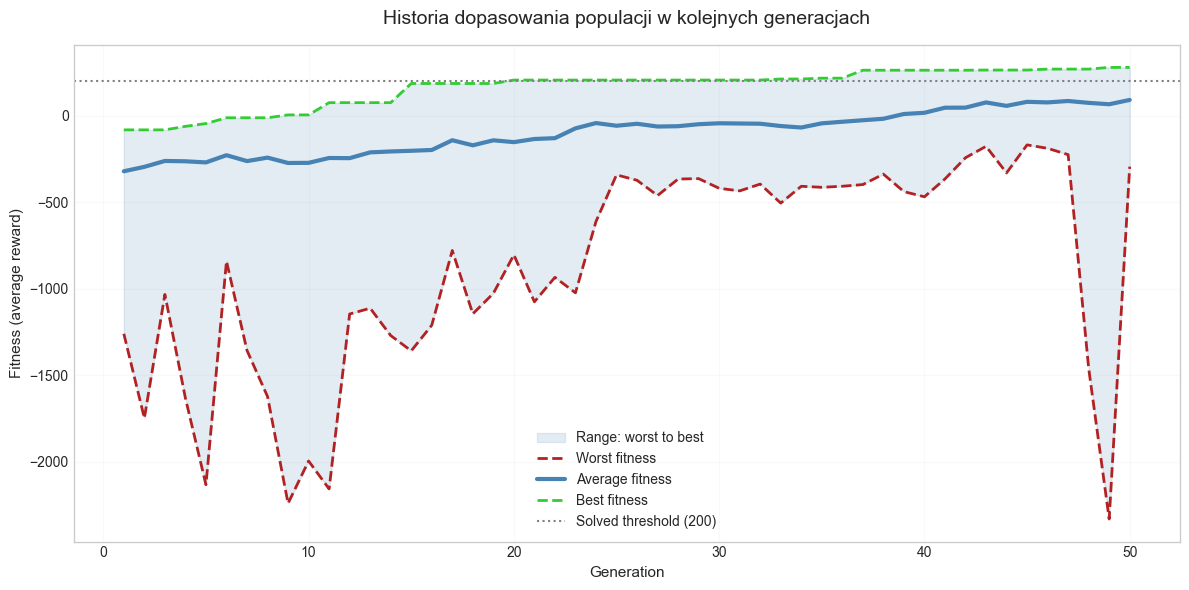

In [9]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

generations = range(1, _GENERATIONS + 1)

plt.figure(figsize=(12, 6))

plt.fill_between(
    generations,
    worst_history,
    best_history,
    color='steelblue',
    alpha=0.15,
    label='Range: worst to best'
)

plt.plot(generations, worst_history, color='firebrick', linestyle='--', linewidth=2, label='Worst fitness')
plt.plot(generations, average_history, color='steelblue', linewidth=3, label='Average fitness')
plt.plot(generations, best_history, color='limegreen', linestyle='--', linewidth=2, label='Best fitness')

plt.axhline(200, color='gray', linestyle=':', linewidth=1.5, label='Solved threshold (200)')

plt.title('Historia dopasowania populacji w kolejnych generacjach', fontsize=14, pad=15)
plt.xlabel('Generation', fontsize=11)
plt.ylabel('Fitness (average reward)', fontsize=11)
plt.grid(alpha=0.1)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Wizualizacja najlepszego osobnika

In [10]:
best_network = best_subject.network

demo_env = gym.make("LunarLander-v3", render_mode="human")
obs, info = demo_env.reset()
done = False
total_reward = 0

while not done:
    action = best_network.forward(obs)
    obs, reward, terminated, truncated, info = demo_env.step(action)
    total_reward += reward
    done = terminated or truncated

demo_env.close()
print("Demo reward:", total_reward)

Demo reward: 240.29136964947716
